# AI4I 2020 Predictive Maintenance — Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
df = pd.read_csv('../data/raw/ai4i2020.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print("\nColumn Names:")
for  col in enumerate(df.columns, 1):
    print(f"{col}")

Dataset Shape: (10000, 14)
Rows: 10,000 | Columns: 14

Column Names:
(1, 'UDI')
(2, 'Product ID')
(3, 'Type')
(4, 'air_temperature')
(5, 'process_temperature')
(6, 'rotational_speed')
(7, 'torque')
(8, 'tool_wear')
(9, 'Machine failure')
(10, 'TWF')
(11, 'HDF')
(12, 'PWF')
(13, 'OSF')
(14, 'RNF')


In [ ]:
print("DATA TYPES AND NULL COUNTS")
print("=" * 50)
print(df.info())

print("\nFIRST 5 ROWS")
print("=" * 50)
df.head()

DATA TYPES AND NULL COUNTS
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   air_temperature      10000 non-null  float64
 4   process_temperature  10000 non-null  float64
 5   rotational_speed   10000 non-null  int64  
 6   torque              10000 non-null  float64
 7   tool_wear          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)


,UDI,Product ID,Type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1000,308.6000,1551,42.8000,0,0,0,0,0,0,0
1,2,L47181,L,298.2000,308.7000,1408,46.3000,3,0,0,0,0,0,0
2,3,L47182,L,298.1000,308.5000,1498,49.4000,5,0,0,0,0,0,0
3,4,L47183,L,298.2000,308.6000,1433,39.5000,7,0,0,0,0,0,0
4,5,L47184,L,298.2000,308.7000,1408,40.0000,9,0,0,0,0,0,0


In [ ]:
print("STATISTICAL SUMMARY — Sensor Features")
print("=" * 50)

sensor_cols = [
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear'
]

df[sensor_cols].describe().round(3)

STATISTICAL SUMMARY — Sensor Features


,air_temperature,process_temperature,rotational_speed,torque,tool_wear
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,300.0050,310.0060,1538.7760,39.9870,107.9510
std,2.0000,1.4840,179.2840,9.9690,63.6540
min,295.3000,305.7000,1168.0000,3.8000,0.0000
25%,298.3000,308.8000,1423.0000,33.2000,53.0000
50%,300.1000,310.1000,1503.0000,40.1000,108.0000
75%,301.5000,311.1000,1612.0000,46.8000,162.0000
max,304.5000,313.8000,2886.0000,76.6000,253.0000


CLASS IMBALANCE ANALYSIS
Total observations : 10,000
Failures (1)       : 339  (3.39%)
No Failures (0)    : 9,661  (96.61%)
Imbalance ratio    : 1 : 28


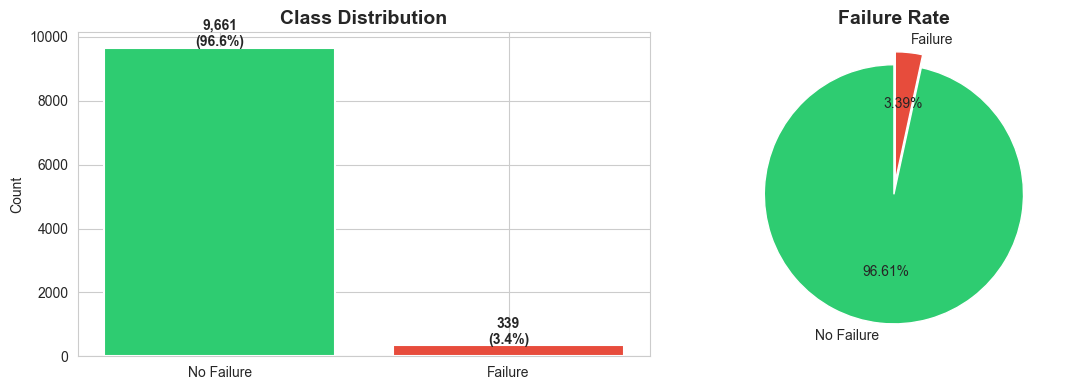

Plot saved.


In [ ]:
print("CLASS IMBALANCE ANALYSIS")
print("=" * 50)

total = len(df)
failures = df['Machine failure'].sum()
no_failures = total - failures

print(f"Total observations : {total:,}")
print(f"Failures (1)       : {failures:,}  ({failures/total*100:.2f}%)")
print(f"No Failures (0)    : {no_failures:,}  ({no_failures/total*100:.2f}%)")
print(f"Imbalance ratio    : 1 : {no_failures/failures:.0f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['No Failure', 'Failure'],
            [no_failures, failures],
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([no_failures, failures]):
    axes[0].text(i, v + 50, f'{v:,}\n({v/total*100:.1f}%)',
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie([no_failures, failures],
            labels=['No Failure', 'Failure'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.2f%%',
            startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Failure Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/01_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved.")

FAILURE MODE ANALYSIS

Total machine failures: 339

Breakdown by failure mode:
  HDF (Heat Dissipation Failure      ): 115  (33.9% of failures)
  OSF (Overstrain Failure            ):  98  (28.9% of failures)
  PWF (Power Failure                 ):  95  (28.0% of failures)
  TWF (Tool Wear Failure             ):  46  (13.6% of failures)
  RNF (Random Failure                ):  19  (5.6% of failures)

Rows with 0 failure modes flagged : 9
Rows with 1 failure mode          : 306
Rows with 2+ failure modes        : 24


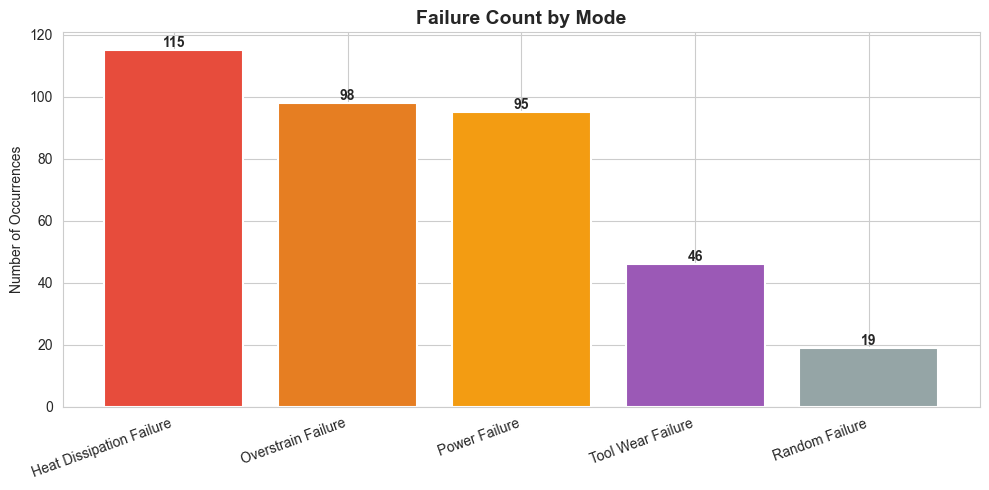

In [ ]:
print("FAILURE MODE ANALYSIS")
print("=" * 50)

failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
mode_names = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure'
}

mode_counts = df[failure_modes].sum().sort_values(ascending=False)

print(f"\nTotal machine failures: {df['Machine failure'].sum()}")
print(f"\nBreakdown by failure mode:")
for mode in mode_counts.index:
    count = mode_counts[mode]
    pct_of_failures = count / df['Machine failure'].sum() * 100
    print(f"  {mode} ({mode_names[mode]:<30}): {count:3d}  ({pct_of_failures:.1f}% of failures)")

# Check overlap — rows with multiple failure modes
df_failures = df[df['Machine failure'] == 1]
df_failures['mode_count'] = df_failures[failure_modes].sum(axis=1)
print(f"\nRows with 0 failure modes flagged : {(df_failures['mode_count'] == 0).sum()}")
print(f"Rows with 1 failure mode          : {(df_failures['mode_count'] == 1).sum()}")
print(f"Rows with 2+ failure modes        : {(df_failures['mode_count'] >= 2).sum()}")

# Bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(
    [mode_names[m] for m in mode_counts.index],
    mode_counts.values,
    color=['#e74c3c', '#e67e22', '#f39c12', '#9b59b6', '#95a5a6'],
    edgecolor='white', linewidth=1.5
)
plt.title('Failure Count by Mode', fontsize=14, fontweight='bold')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, mode_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/02_failure_modes.png', dpi=100, bbox_inches='tight')
plt.show()

QUALITY VARIANT ANALYSIS
      failures  total  failure_rate
Type                               
H           21   1003        2.0900
L          235   6000        3.9200
M           83   2997        2.7700


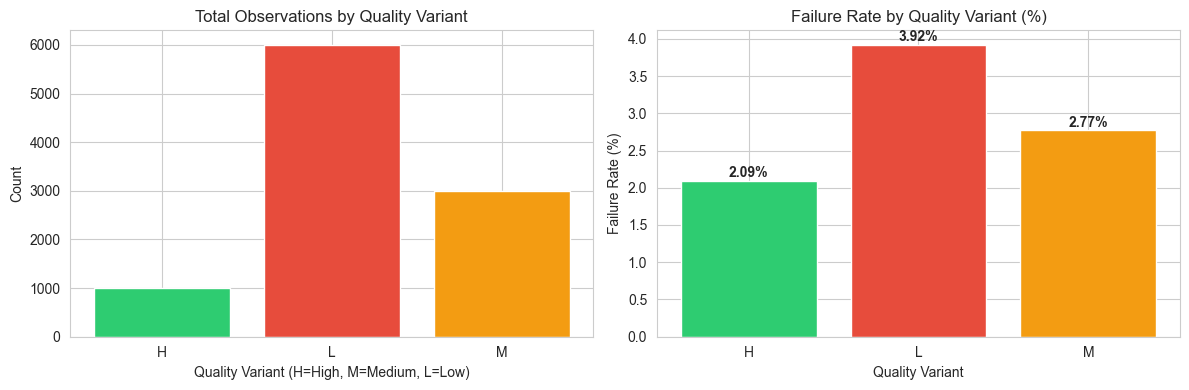

In [ ]:
print("QUALITY VARIANT ANALYSIS")
print("=" * 50)

# Extract quality type from Product ID
df['Type'] = df['Product ID'].str[0]

type_failure = df.groupby('Type')['Machine failure'].agg(['sum', 'count'])
type_failure.columns = ['failures', 'total']
type_failure['failure_rate'] = type_failure['failures'] / type_failure['total'] * 100

print(type_failure.round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'H': '#2ecc71', 'M': '#f39c12', 'L': '#e74c3c'}

# Count per type
axes[0].bar(type_failure.index,
            type_failure['total'],
            color=[colors[t] for t in type_failure.index])
axes[0].set_title('Total Observations by Quality Variant')
axes[0].set_xlabel('Quality Variant (H=High, M=Medium, L=Low)')
axes[0].set_ylabel('Count')

# Failure rate per type
axes[1].bar(type_failure.index,
            type_failure['failure_rate'],
            color=[colors[t] for t in type_failure.index])
axes[1].set_title('Failure Rate by Quality Variant (%)')
axes[1].set_xlabel('Quality Variant')
axes[1].set_ylabel('Failure Rate (%)')
for i, (idx, row) in enumerate(type_failure.iterrows()):
    axes[1].text(i, row['failure_rate'] + 0.05,
                 f"{row['failure_rate']:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/03_quality_variant.png', dpi=100, bbox_inches='tight')
plt.show()

This code analyzes how machine failures vary across different product quality variants (High, Medium, and Low). It extracts the quality category from the Product ID, calculates the total number of products, total failures, and failure rate for each quality level, displays these statistics in a summary table, and visualizes the results using two bar charts: one showing the number of observations in each quality category and another showing the corresponding failure rates. This helps determine whether product quality is associated with a higher or lower likelihood of machine failure.

SENSOR FEATURE DISTRIBUTIONS
Comparing failure vs no-failure observations


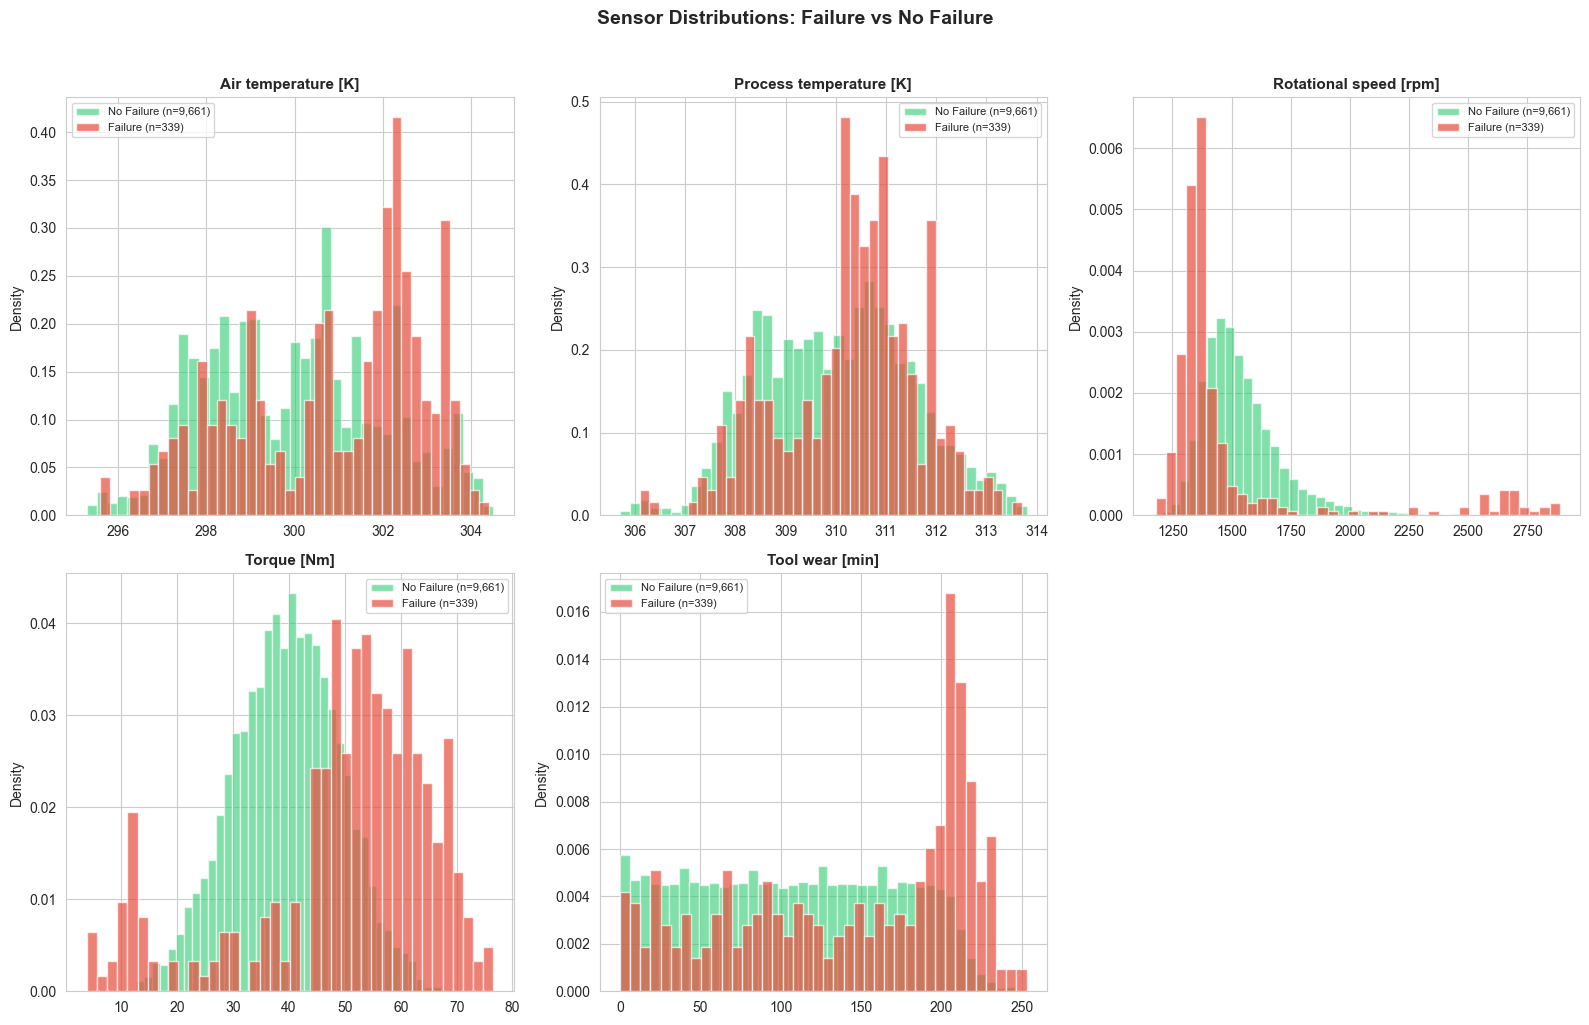

In [ ]:
print("SENSOR FEATURE DISTRIBUTIONS")
print("Comparing failure vs no-failure observations")
print("=" * 50)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features = [
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear'
]

for i, feature in enumerate(features):
    ax = axes[i]

    no_fail = df[df['Machine failure'] == 0][feature]
    fail = df[df['Machine failure'] == 1][feature]

    ax.hist(no_fail, bins=40, alpha=0.6, color='#2ecc71',
            label=f'No Failure (n={len(no_fail):,})', density=True)
    ax.hist(fail, bins=40, alpha=0.7, color='#e74c3c',
            label=f'Failure (n={len(fail):,})', density=True)

    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Sensor Distributions: Failure vs No Failure',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/04_sensor_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

This code compares the distributions of five key sensor measurements between machines that failed and machines that did not fail. For each sensor feature, it creates overlapping histograms showing how the values are distributed across the two classes. By visualizing these distributions, it becomes possible to identify whether certain sensor readings, such as higher temperatures, unusual rotational speeds, greater torque, or increased tool wear, are associated with machine failures. This helps determine which features may be useful predictors for machine failure in later machine learning models.

In [ ]:
print("FEATURE ENGINEERING")
print("=" * 50)

# Engineer the 4 derived features
df['temp_diff'] = df['process_temperature'] - df['air_temperature']
df['power'] = df['torque'] * df['rotational_speed'] * (2 * np.pi / 60)
df['tool_wear_torque'] = df['tool_wear'] * df['torque']
df['quality_encoded'] = df['Type'].map({'H': 2, 'M': 1, 'L': 0})

engineered = ['temp_diff', 'power', 'tool_wear_torque', 'quality_encoded']

print("Engineered features added:")
for f in engineered:
    print(f"  {f}: min={df[f].min():.2f}, max={df[f].max():.2f}, mean={df[f].mean():.2f}")

# Correlation with machine failure
all_features = [
    'air_temperature', 'process_temperature',
    'rotational_speed', 'torque', 'tool_wear',
    'temp_diff', 'power', 'tool_wear_torque', 'quality_encoded'
]

correlations = df[all_features + ['Machine failure']]\
    .corr()['Machine failure']\
    .drop('Machine failure')\
    .abs()\
    .sort_values(ascending=False)

print("\nFeature Correlation with Machine Failure (absolute):")
for feat, corr in correlations.items():
    bar = '█' * int(corr * 40)
    print(f"  {feat:<35} {corr:.4f}  {bar}")

FEATURE ENGINEERING
Engineered features added:
  temp_diff: min=7.60, max=12.10, mean=10.00
  power: min=1148.44, max=10469.92, mean=6279.74
  tool_wear_torque: min=0.00, max=16497.00, mean=4314.66
  quality_encoded: min=0.00, max=2.00, mean=0.50

Feature Correlation with Machine Failure (absolute):
  torque                         0.1913  ███████
  tool_wear_torque                    0.1904  ███████
  power                               0.1760  ███████
  temp_diff                           0.1117  ████
  tool_wear                     0.1054  ████
  air_temperature                 0.0826  ███
  rotational_speed              0.0442  █
  quality_encoded                     0.0367  █
  process_temperature             0.0359  █


This code performs feature engineering by creating four new variables (temp_diff, power, tool_wear_torque, and quality_encoded) from existing sensor and product information. These engineered features are designed to capture relationships that may not be obvious in the original data. After creating them, the code prints summary statistics to verify the new features and then calculates the absolute correlation of both original and engineered features with the target variable, Machine failure. The final output ranks features by their relationship strength with machine failures, helping identify which variables may be most useful for predictive modeling.

VALIDATING HDF FAILURE CONDITION
temp_diff < 8.6 AND rotational_speed < 1380 → HDF fires
Actual HDF failures         : 115
Rows meeting HDF condition  : 115
Condition captures HDF rows : 115 (100.0%)


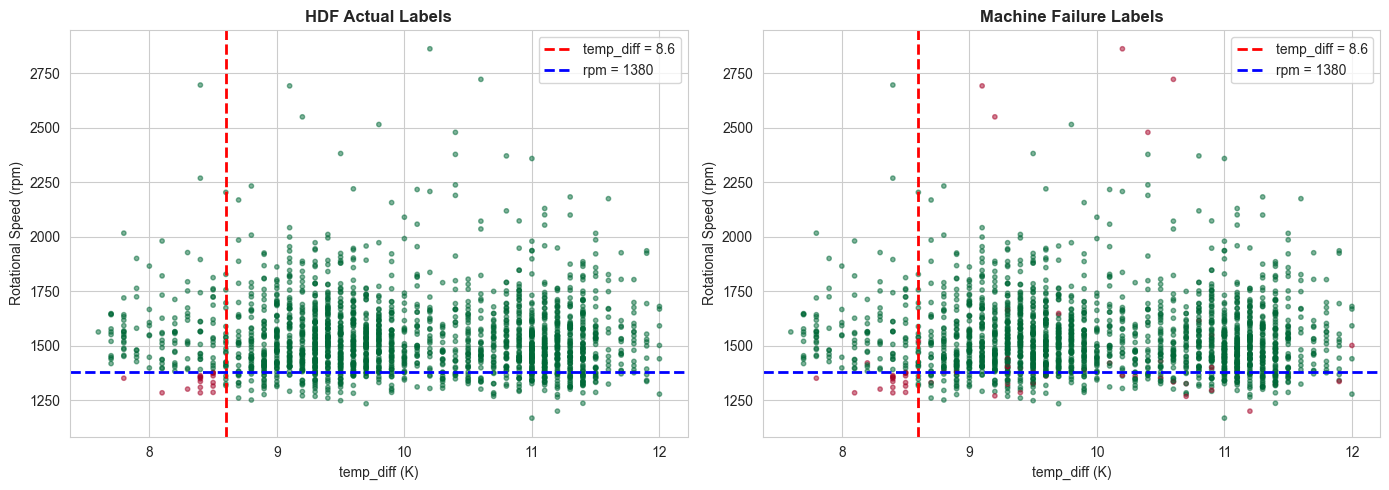

In [ ]:
print("VALIDATING HDF FAILURE CONDITION")
print("temp_diff < 8.6 AND rotational_speed < 1380 → HDF fires")
print("=" * 50)

hdf_condition = (df['temp_diff'] < 8.6) & (df['rotational_speed'] < 1380)

actual_hdf = df['HDF'].sum()
predicted_hdf = hdf_condition.sum()
overlap = (hdf_condition & (df['HDF'] == 1)).sum()

print(f"Actual HDF failures         : {actual_hdf}")
print(f"Rows meeting HDF condition  : {predicted_hdf}")
print(f"Condition captures HDF rows : {overlap} ({overlap/actual_hdf*100:.1f}%)")

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df.sample(2000, random_state=42)

for ax, title, hue_col in [
    (axes[0], 'HDF Actual Labels', 'HDF'),
    (axes[1], 'Machine Failure Labels', 'Machine failure')
]:
    scatter = ax.scatter(
        sample['temp_diff'],
        sample['rotational_speed'],
        c=sample[hue_col],
        cmap='RdYlGn_r',
        alpha=0.5, s=10
    )
    ax.axvline(x=8.6, color='red', linestyle='--', linewidth=2, label='temp_diff = 8.6')
    ax.axhline(y=1380, color='blue', linestyle='--', linewidth=2, label='rpm = 1380')
    ax.set_xlabel('temp_diff (K)')
    ax.set_ylabel('Rotational Speed (rpm)')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/05_hdf_validation.png', dpi=100, bbox_inches='tight')
plt.show()

This code validates whether the dataset's Heat Dissipation Failure (HDF) labels follow the expected failure rule: temperature difference below 8.6 K and rotational speed below 1380 RPM. It creates a Boolean condition representing this rule, compares it against the actual HDF labels, and measures how many HDF failures are correctly captured. The code then visualizes the relationship using scatter plots of temperature difference versus rotational speed, with threshold lines marking the HDF boundaries. This helps verify that the failure labels in the dataset are consistent with the underlying failure-generation logic and provides a visual understanding of where HDF failures occur in the feature space.

HDF (Heat Dissipation Failure) is being validated is that, in this dataset, HDF is one of the failure types that has a clearly defined rule based on the available features.

Your code is checking whether the dataset follows the documented condition

CORRELATION HEATMAP — All Features


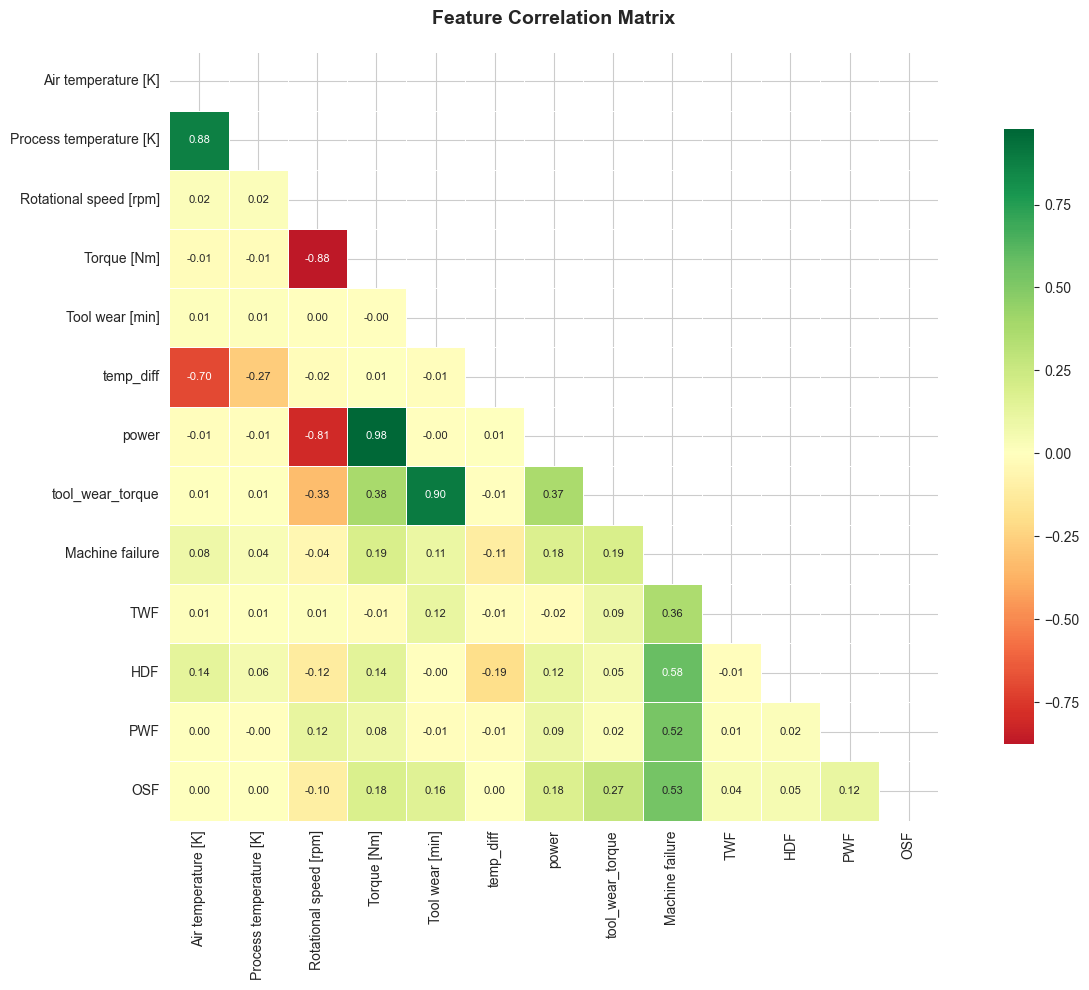

In [ ]:
print("CORRELATION HEATMAP — All Features")
print("=" * 50)

feature_cols = [
    'air_temperature', 'process_temperature',
    'rotational_speed', 'torque', 'tool_wear',
    'temp_diff', 'power', 'tool_wear_torque',
    'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF'
]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/processed/06_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

This code computes the pairwise correlations between all major sensor measurements, engineered features, and failure indicators, then visualizes those relationships using a heatmap. The heatmap makes it easy to identify which features are strongly related to machine failures, which engineered features provide additional information, and whether any variables are highly correlated with each other. This analysis is particularly useful before model building because it helps in feature selection, detecting redundant variables, and understanding the overall structure of the dataset.

In [ ]:
print("=" * 60)
print("EDA SUMMARY — Key Findings")
print("=" * 60)

print(f"""
DATASET:
  Rows: 10,000 | Features: 14 | Failures: {df['Machine failure'].sum()}

CLASS IMBALANCE:
  Failure rate: {df['Machine failure'].mean()*100:.2f}%
  Imbalance ratio: 1:{int((1-df['Machine failure'].mean())/df['Machine failure'].mean())}
  → Will use: SMOTE + class_weight='balanced' + threshold tuning

FAILURE MODES:
  Most common: HDF ({df['HDF'].sum()}) and PWF ({df['PWF'].sum()})
  Least common: RNF ({df['RNF'].sum()}) — skip in modelling (random noise)
  Co-occurring failures exist — use multi-label approach

QUALITY VARIANTS:
  L (Low)    : {(df['Type']=='L').sum():,} rows — fastest tool wear
  M (Medium) : {(df['Type']=='M').sum():,} rows
  H (High)   : {(df['Type']=='H').sum():,} rows — slowest tool wear

TOP CORRELATED FEATURES WITH FAILURE:
""")

for feat, corr in correlations.head(5).items():
    print(f"  {feat:<35} r={corr:.4f}")

print(f"""
ENGINEERED FEATURES:
  temp_diff        → directly predicts HDF (r={df['temp_diff'].corr(df['HDF']):.3f} with HDF)
  tool_wear_torque → directly predicts OSF
  power            → directly predicts PWF

NEXT STEP:
  → 02_ai4i_training.ipynb: Train XGBoost models on these findings
""")

EDA SUMMARY — Key Findings

DATASET:
  Rows: 10,000 | Features: 14 | Failures: 339

CLASS IMBALANCE:
  Failure rate: 3.39%
  Imbalance ratio: 1:28
  → Will use: SMOTE + class_weight='balanced' + threshold tuning

FAILURE MODES:
  Most common: HDF (115) and PWF (95)
  Least common: RNF (19) — skip in modelling (random noise)
  Co-occurring failures exist — use multi-label approach

QUALITY VARIANTS:
  L (Low)    : 6,000 rows — fastest tool wear
  M (Medium) : 2,997 rows
  H (High)   : 1,003 rows — slowest tool wear

TOP CORRELATED FEATURES WITH FAILURE:

  torque                         r=0.1913
  tool_wear_torque                    r=0.1904
  power                               r=0.1760
  temp_diff                           r=0.1117
  tool_wear                     r=0.1054

ENGINEERED FEATURES:
  temp_diff        → directly predicts HDF (r=-0.191 with HDF)
  tool_wear_torque → directly predicts OSF
  power            → directly predicts PWF

NEXT STEP:
  → 02_ai4i_training.ipynb: Train

EDA shows that:

The dataset is highly imbalanced (3.39% failures).
Torque, power, and tool wear are the strongest predictors of failure.
Your engineered features (temp_diff, power, tool_wear_torque) successfully capture the physical mechanisms behind HDF, PWF, and OSF.
The documented HDF rule is perfectly reflected in the data.
Multiple failure modes can occur together, making multi-label classification appropriate.
Special handling is needed for class imbalance and a small number of inconsistent labels before model training.